<a href="https://colab.research.google.com/github/yashuKIET/IMAGE-TRANSFORMATION-DECOMPOSER/blob/main/IMAGE_TRANSFORMATION_DECOMPOSER_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        IMAGE TRANSFORMATION DECOMPOSER (B10)

TRANSFORMATION MATRIX A:
[[2. 1.]
 [1. 2.]]

-----------------------------------------------------------------
1. EIGENVALUES
-----------------------------------------------------------------
λ1 = 3.0000
λ2 = 1.0000

-----------------------------------------------------------------
2. EIGENVECTORS
-----------------------------------------------------------------
v1 = [0.7071, 0.7071]
v2 = [-0.7071, 0.7071]

-----------------------------------------------------------------
3. CHARACTERISTIC EQUATION
-----------------------------------------------------------------
Trace(A)      = 4.0000
Determinant(A)= 3.0000

λ² - (4.0000)λ + (3.0000) = 0

-----------------------------------------------------------------
4. ROTATION + STRETCHING DECOMPOSITION
-----------------------------------------------------------------

Rotation / reflection component R:
[[ 1. -0.]
 [ 0.  1.]]

Stretching component S:
[[2. 1.]
 [1. 2.]]

Verification: R × S
[[2. 1.]
 

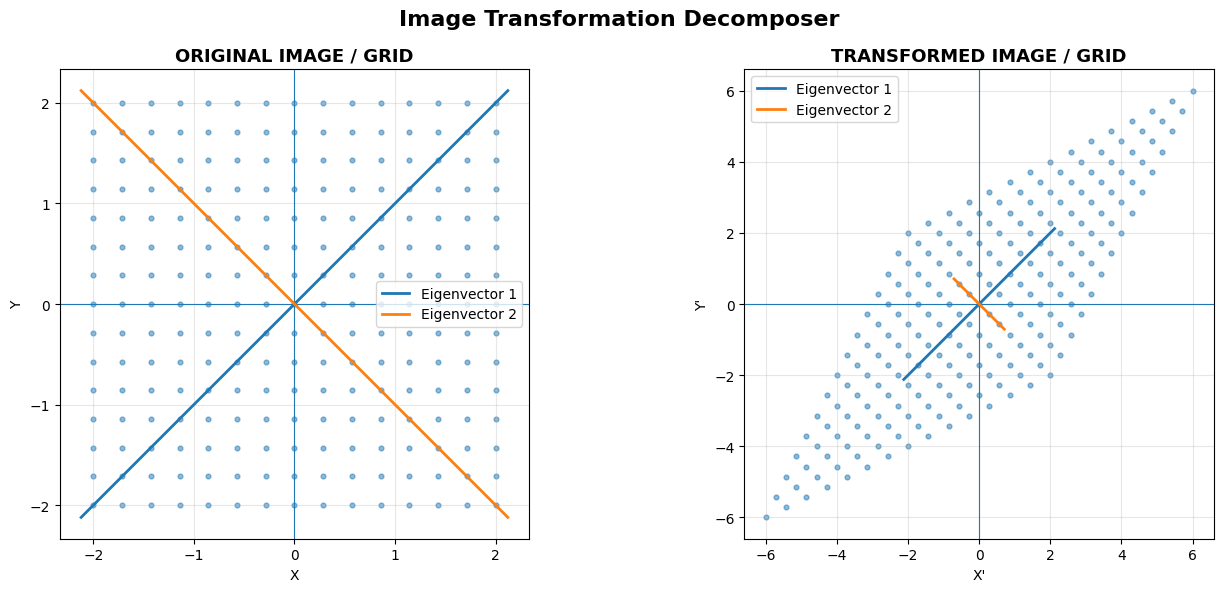


PROJECT CONCLUSION

The matrix A transforms every point of the image/grid.

Eigenvectors identify special directions where:
    A v = λ v

Therefore:
    • Direction remains unchanged
    • Only stretching/compression occurs
    • Eigenvalue λ tells the scaling factor

The polar decomposition:
    A = R S

separates the transformation into:
    R → rotation/reflection
    S → stretching/compression

The graph shows the transformation visually.



Button(button_style='primary', description='TRANSFORM', icon='play', style=ButtonStyle())

In [ ]:
# ============================================================
# IMAGE TRANSFORMATION DECOMPOSER (B10)
# Eigenvalues + Eigenvectors + Rotation + Stretching
# Google Colab - Single Cell
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from IPython.display import display, clear_output
import ipywidgets as widgets

# -----------------------------
# TITLE
# -----------------------------
print("=" * 65)
print("        IMAGE TRANSFORMATION DECOMPOSER (B10)")
print("=" * 65)
print("Enter a 2×2 transformation matrix and explore:")
print("• Eigenvalues")
print("• Eigenvectors")
print("• Stretching / compression")
print("• Rotation + stretching decomposition")
print("• Visual transformation of an image/grid")
print("=" * 65)

# -----------------------------
# INPUT MATRIX
# -----------------------------
a = widgets.FloatText(value=2, description='a =', style={'description_width': '40px'})
b = widgets.FloatText(value=1, description='b =', style={'description_width': '40px'})
c = widgets.FloatText(value=1, description='c =', style={'description_width': '40px'})
d = widgets.FloatText(value=2, description='d =', style={'description_width': '40px'})

button = widgets.Button(
    description='TRANSFORM',
    button_style='primary',
    icon='play'
)

display(widgets.HBox([a, b]))
display(widgets.HBox([c, d]))
display(button)

# -----------------------------
# MAIN FUNCTION
# -----------------------------
def transform_matrix(change=None):

    clear_output(wait=True)

    print("=" * 65)
    print("        IMAGE TRANSFORMATION DECOMPOSER (B10)")
    print("=" * 65)

    A = np.array([
        [a.value, b.value],
        [c.value, d.value]
    ], dtype=float)

    print("\nTRANSFORMATION MATRIX A:")
    print(A)

    # --------------------------------------------------------
    # EIGENVALUES & EIGENVECTORS
    # --------------------------------------------------------
    eigenvalues, eigenvectors = np.linalg.eig(A)

    print("\n" + "-" * 65)
    print("1. EIGENVALUES")
    print("-" * 65)

    for i, lam in enumerate(eigenvalues):
        print(f"λ{i+1} = {lam:.4f}")

    print("\n" + "-" * 65)
    print("2. EIGENVECTORS")
    print("-" * 65)

    real_eigen = True

    for i in range(len(eigenvalues)):
        if abs(eigenvalues[i].imag) > 1e-8:
            real_eigen = False
            print(f"Eigenvalue λ{i+1} is complex.")
        else:
            v = np.real(eigenvectors[:, i])
            v = v / np.linalg.norm(v)
            print(f"v{i+1} = [{v[0]:.4f}, {v[1]:.4f}]")

    # --------------------------------------------------------
    # CHARACTERISTIC EQUATION
    # --------------------------------------------------------
    trace = np.trace(A)
    determinant = np.linalg.det(A)

    print("\n" + "-" * 65)
    print("3. CHARACTERISTIC EQUATION")
    print("-" * 65)

    print(f"Trace(A)      = {trace:.4f}")
    print(f"Determinant(A)= {determinant:.4f}")
    print(f"\nλ² - ({trace:.4f})λ + ({determinant:.4f}) = 0")

    # --------------------------------------------------------
    # POLAR DECOMPOSITION
    # A = R S
    # --------------------------------------------------------
    print("\n" + "-" * 65)
    print("4. ROTATION + STRETCHING DECOMPOSITION")
    print("-" * 65)

    try:
        U, singular_values, Vt = np.linalg.svd(A)

        R = U @ Vt
        S = Vt.T @ np.diag(singular_values) @ Vt

        print("\nRotation / reflection component R:")
        print(np.round(R, 4))

        print("\nStretching component S:")
        print(np.round(S, 4))

        print("\nVerification: R × S")
        print(np.round(R @ S, 4))

        angle = np.arctan2(R[1, 0], R[0, 0])
        angle_deg = np.degrees(angle)

        print(f"\nApproximate rotation angle = {angle_deg:.2f}°")

        print("\nStretch factors (singular values):")
        for i, sv in enumerate(singular_values):
            print(f"Stretch {i+1} = {sv:.4f}")

    except Exception as e:
        print("Decomposition error:", e)

    # --------------------------------------------------------
    # EIGENVECTOR DEMONSTRATION
    # --------------------------------------------------------
    print("\n" + "-" * 65)
    print("5. EIGENVECTOR CHECK")
    print("-" * 65)

    if real_eigen:

        for i in range(len(eigenvalues)):

            lam = np.real(eigenvalues[i])
            v = np.real(eigenvectors[:, i])
            v = v / np.linalg.norm(v)

            transformed = A @ v

            print(f"\nEigenvector {i+1}:")
            print(f"v{i+1} = {np.round(v, 4)}")

            print(f"A v{i+1} = {np.round(transformed, 4)}")

            print(f"λ{i+1} v{i+1} = {np.round(lam * v, 4)}")

            print(
                f"→ Direction unchanged; scaling factor = {lam:.4f}"
            )

    else:
        print("\nThis matrix does not have two real eigenvector directions.")
        print("The visual transformation will still be shown.")

    # --------------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Grid/image-like object
    x = np.linspace(-2, 2, 15)
    y = np.linspace(-2, 2, 15)

    X, Y = np.meshgrid(x, y)

    points = np.vstack([X.flatten(), Y.flatten()])
    transformed_points = A @ points

    X2 = transformed_points[0].reshape(X.shape)
    Y2 = transformed_points[1].reshape(Y.shape)

    # ORIGINAL
    ax = axes[0]

    ax.scatter(
        points[0],
        points[1],
        s=12,
        alpha=0.5
    )

    ax.set_title("ORIGINAL IMAGE / GRID", fontsize=13, fontweight='bold')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # TRANSFORMED
    ax = axes[1]

    ax.scatter(
        transformed_points[0],
        transformed_points[1],
        s=12,
        alpha=0.5
    )

    ax.set_title(
        "TRANSFORMED IMAGE / GRID",
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel("X'")
    ax.set_ylabel("Y'")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # --------------------------------------------------------
    # DRAW EIGENVECTOR DIRECTIONS
    # --------------------------------------------------------
    if real_eigen:

        for i in range(len(eigenvalues)):

            v = np.real(eigenvectors[:, i])
            v = v / np.linalg.norm(v)

            length = 3

            # Original eigenvector
            axes[0].plot(
                [-length*v[0], length*v[0]],
                [-length*v[1], length*v[1]],
                linewidth=2,
                label=f"Eigenvector {i+1}"
            )

            # Transformed eigenvector
            tv = A @ v

            axes[1].plot(
                [-tv[0], tv[0]],
                [-tv[1], tv[1]],
                linewidth=2,
                label=f"Eigenvector {i+1}"
            )

    axes[0].legend()
    axes[1].legend()

    plt.suptitle(
        "Image Transformation Decomposer",
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 65)
    print("PROJECT CONCLUSION")
    print("=" * 65)

    print("""
The matrix A transforms every point of the image/grid.

Eigenvectors identify special directions where:
    A v = λ v

Therefore:
    • Direction remains unchanged
    • Only stretching/compression occurs
    • Eigenvalue λ tells the scaling factor

The polar decomposition:
    A = R S

separates the transformation into:
    R → rotation/reflection
    S → stretching/compression

The graph shows the transformation visually.
""")

    # Re-display controls
    display(widgets.HBox([a, b]))
    display(widgets.HBox([c, d]))
    display(button)


# Connect button
button.on_click(transform_matrix)

# Run once automatically
transform_matrix()